In [6]:
#transportation problem_minimize cost
# 2 factories supply 3 stores
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [ ]:
#cost matrix

cost=np.array([[2,3,1],
               [5,4,8]])

#supply and demand

supply=[30,40]
demand=[25,35,10]

#display  cost matrix as DataFrame

df_cost=pd.DataFrame(cost,
                     index=["factory1","factory2"],
                     columns=["storeA","storeB","storeC"])

print("      ========cost matrix======  ")
print(df_cost)
print("\n supply: ",supply)
print("demand: ",demand)

      ========cost matrix======  
          storeA  storeB  storeC
factory1       2       3       1
factory2       5       4       8

 supply:  [30, 40]
demand:  [25, 35, 10]


In [8]:
# solve transportation problem with liprog
#variables:x11,x12,x13,x21,x22,x23
#(xij=units from factory i to j)

c = cost.flatten() #[2,3,1,5,4,8]

#supply constraints (<=)
A_supply = [[1,1,1,0,0,0],      #factory1:x11,x12,x13         
            [0,0,0,1,1,1]]      #factory2:x21,x22,x23

# demand constraints (>=)  -> multiplyby -1

A_demand = [[-1,0,0,-1,0,0],   #storeA:x11+x21 >= 25
            [0,-1,0,0,-1,0],   #storeB:x12+x22 >= 35
            [0,0,-1,0,0,-1]]   #storeC:x13+x23 >= 10

A = A_supply + A_demand

b=[30,40,-25,-35,-10]

result=linprog(c , A_ub= A ,b_ub= b , bounds=[(0,None)]*6)

print("min cost: ",round(result.fun,2))

x = result.x.reshape(2,3).round(2)

df_result=pd.DataFrame(x,
                    index=["factory1","factory2"],
                    columns=["storeA","storeB","storeC"]) 
print("\n ===distribution===")
print(df_result)


min cost:  215.0

 ===distribution===
          storeA  storeB  storeC
factory1    20.0     0.0    10.0
factory2     5.0    35.0     0.0


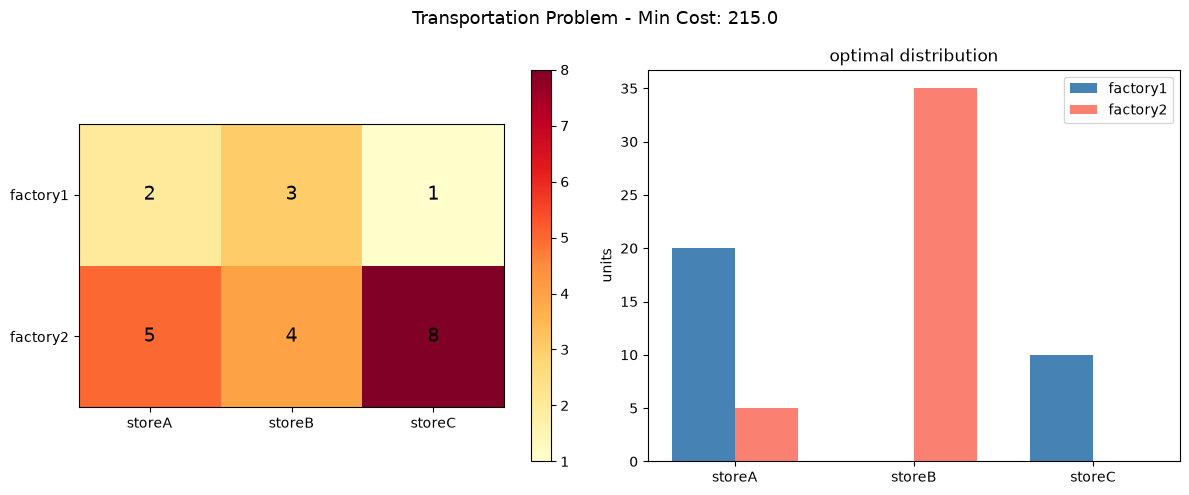

In [14]:
#visualization_transportation


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#-------------------1)cost matrix Reatmap------------

ax1=axes[0]

im = ax1.imshow(cost,cmap="YlOrRd")


ax1.set_xticks([0,1,2])
ax1.set_yticks([0,1])
ax1.set_xticklabels(["storeA","storeB","storeC"])
ax1.set_yticklabels(["factory1","factory2"])

for i in range(2):
    for j in range(3):
        ax1.text(j,i,cost[i,j],ha="center",va="center",fontsize=14)
plt.colorbar(im,ax=ax1)


#-----------2)distribution on bar chart-----------
ax2=axes[1]

x = np.arange(3)

width=0.35

ax2.bar(x-width/2, df_result.iloc[0],width,label="factory1",color="steelblue")
ax2.bar(x+width/2, df_result.iloc[1],width,label="factory2",color="salmon")

ax2.set_xticks(x)
ax2.set_xticklabels(["storeA","storeB","storeC"])

ax2.set_title("optimal distribution")
ax2.set_ylabel("units")

ax2.legend() 


plt.suptitle(f"Transportation Problem - Min Cost: {result.fun}", fontsize=13)
plt.tight_layout()
plt.show()




In [15]:
# result sumary
print("===optimal distribution===")
print(df_result)
print(f"\n Min total cost: {result.fun}")
print("\n====verification====")
print("supply used_factory1: ",df_result.iloc[0].sum(),"/30")
print("supply used_factory2: ",df_result.iloc[1].sum(),"/40")
print("demand met_storeA: ",df_result["storeA"].sum(),"/25")
print("demand met_storeB: ",df_result["storeB"].sum(),"/35")
print("demand met_storeC: ",df_result["storeC"].sum(),"/10")

===optimal distribution===
          storeA  storeB  storeC
factory1    20.0     0.0    10.0
factory2     5.0    35.0     0.0

 Min total cost: 215.0

====verification====
supply used_factory1:  30.0 /30
supply used_factory2:  40.0 /40
demand met_storeA:  25.0 /25
demand met_storeB:  35.0 /35
demand met_storeC:  10.0 /10
